In [1]:
import fiftyone.zoo as foz
import fiftyone as fo
from fiftyone import ViewField as F
import numpy as np
from PIL import Image
import shutil
import os
from sklearn.model_selection import train_test_split
from pathlib import Path
import tensorflow as tf
import matplotlib.pyplot as plt
import torch
import torch.nn
from torch.utils.data import DataLoader
import sys
from unet_model import UNet
from torchsummary import summary
from loss_function import FocalLoss, final_loss
from augmentations import train_transform, test_transform
from helper_functions import process_and_save, analyze_class_distribution, load_image_and_mask
from segmentation_dataset import SegmentationDataset
from model_training_functions import EarlyStopping, compute_confusion_per_class, compute_metrics
from visualisation_functions import visualize_predictions, preprocess_web_image, colorize_mask

sys.path.append("/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl")

/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


### 1) Download images from openimages

In [2]:
images = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["segmentations"],
    classes=["Cat", "Dog", "Car"],
    max_samples=5000,
)

Necessary images already downloaded
Existing download of split 'train' is sufficient
Loading existing dataset 'open-images-v7-train-5000'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


### 2) Filter and combine masks

In [3]:
# keep only images that have at least one target class
samples_with_targets = images.match(
    F("ground_truth.detections").filter(
        F("label").is_in(["Cat", "Dog", "Car"])
    ).length() > 0
)

# within filtered images, keep only the target classes
filtered_view = samples_with_targets.filter_labels(
    "ground_truth",
    F("label").is_in(["Cat", "Dog", "Car"])
)

export_dir = "/Users/jekaterinasergejeva/fiftyone/open-images-v7/train/labels/filtered_masks"

if os.path.exists(export_dir):
    shutil.rmtree(export_dir)

filtered_view.export(
    export_dir=export_dir,
    dataset_type=fo.types.ImageSegmentationDirectory,
    label_field="ground_truth"
)

 100% |███████████████| 1105/1105 [2.4s elapsed, 0s remaining, 478.1 samples/s]      


In [4]:
filtered_view.compute_metadata()

output_dir = "/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/combined_masks"
os.makedirs(output_dir, exist_ok=True)

# 0 for background, 1 for Cat, 2 for Dog, 3 for Car
class_map = {"Cat": 1, "Dog": 2, "Car": 3}

for sample in filtered_view:
    if sample.metadata is None:
        continue
        
    w, h = sample.metadata.width, sample.metadata.height
    
    combined_mask = np.zeros((h, w), dtype=np.uint8)

    if sample.ground_truth and sample.ground_truth.detections:
        for det in sample.ground_truth.detections:
            if det.mask is not None:
                # Bounding box format: [top-left-x, top-left-y, width, height] (relative 0-1)
                rx, ry, rw, rh = det.bounding_box
                x0, y0 = int(round(rx * w)), int(round(ry * h))
                bw, bh = int(round(rw * w)), int(round(rh * h))

                # Resize the detection mask to match the absolute bounding box size
                mask_img = Image.fromarray(det.mask)
                mask_resized = mask_img.resize((bw, bh), Image.NEAREST)
                mask_bool = np.array(mask_resized, dtype=bool)

                # Crop to image boundaries to prevent boundary errors
                x1, y1 = min(x0 + bw, w), min(y0 + bh, h)
                crop_w, crop_h = x1 - x0, y1 - y0

                if crop_w > 0 and crop_h > 0:
                    target_region = combined_mask[y0:y1, x0:x1]
                    mask_bool_cropped = mask_bool[:crop_h, :crop_w]
                    
                    # Encode pixels based on class map
                    target_region[mask_bool_cropped] = class_map[det.label]

    base_name = os.path.basename(sample.filepath)
    mask_filename = os.path.splitext(base_name)[0] + ".png"
    mask_path = os.path.join(output_dir, mask_filename)
    
    visual_mask = combined_mask * 80  
    Image.fromarray(visual_mask).save(mask_path)

print(f"Masks successfully combined and saved to: {output_dir}")

Masks successfully combined and saved to: /Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/combined_masks


In [5]:
filtered_with_seg = 0

for s in filtered_view:
    if s.ground_truth and s.ground_truth.detections:
        if any(det.mask is not None for det in s.ground_truth.detections):
            filtered_with_seg += 1

print(f"Images in filtered_view: {len(filtered_view)}")
print(f"Images in filtered_view that actually have segmentation masks: {filtered_with_seg}")

Images in filtered_view: 1105
Images in filtered_view that actually have segmentation masks: 1105


### 3) Data Augmentations

In [6]:
# directories for train/test images and masks
base_dir = Path.cwd()
masks_dir = os.path.join(base_dir, "combined_masks")

train_img_dir = os.path.join(base_dir, "dataset", "train", "images")
train_mask_dir = os.path.join(base_dir, "dataset", "train", "masks")
test_img_dir = os.path.join(base_dir, "dataset", "test", "images")
test_mask_dir = os.path.join(base_dir, "dataset", "test", "masks")

for d in [train_img_dir, train_mask_dir, test_img_dir, test_mask_dir]:
    os.makedirs(d, exist_ok=True)

In [7]:
# Collect all valid image/mask pairs
image_paths = []
mask_paths = []

for sample in filtered_view:
    base_name = os.path.basename(sample.filepath)
    mask_filename = os.path.splitext(base_name)[0] + ".png"
    mask_path = os.path.join(masks_dir, mask_filename)
    
    if os.path.exists(mask_path):
        image_paths.append(sample.filepath)
        mask_paths.append(mask_path)

In [8]:
# Split the dataset into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(image_paths, mask_paths, test_size=0.1, random_state=42)

In [9]:
# Process train and test sets
print(f"Processing {len(X_train)} training images...")
process_and_save(X_train, y_train, train_transform, train_img_dir, train_mask_dir)

print(f"Processing {len(X_test)} testing images...")
process_and_save(X_test, y_test, test_transform, test_img_dir, test_mask_dir)

Processing 994 training images...
Processing 111 testing images...


In [10]:
# check class distribution in both train and test masks
analyze_class_distribution([train_mask_dir, test_mask_dir])

Total masks analyzed: 5174

Masks containing each class:
  Class 0: 5173 masks
  Class 1: 1829 masks
  Class 2: 1892 masks
  Class 3: 1489 masks

Total pixel counts per class:
  Class 0: 257488131 pixels (75.9365%)
  Class 1: 26795055 pixels (7.9022%)
  Class 2: 32838368 pixels (9.6845%)
  Class 3: 21961710 pixels (6.4768%)


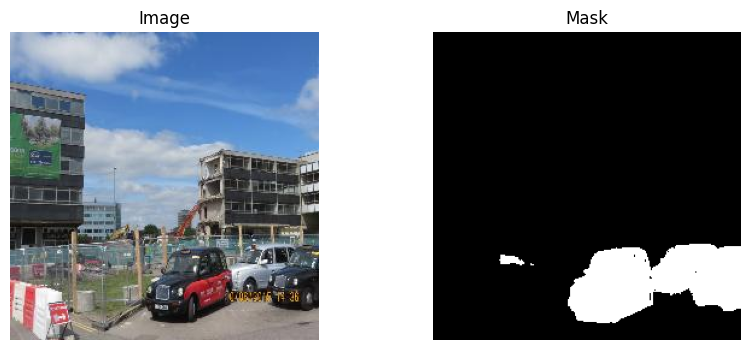

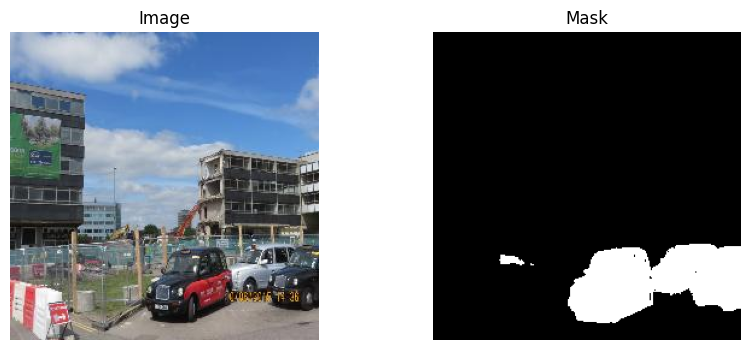

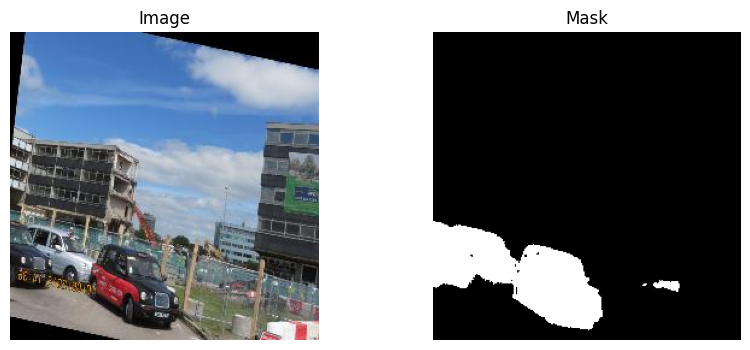

In [12]:
train_img_paths = sorted([os.path.join(train_img_dir, f) for f in os.listdir(train_img_dir) if f.endswith('.jpg')])
train_mask_paths = sorted([os.path.join(train_mask_dir, f) for f in os.listdir(train_mask_dir) if f.endswith('.png')])

# Augmented images and masks examples
for i in range(3):
    img_path = train_img_paths[i]
    mask_path = train_mask_paths[i]
    img = np.array(Image.open(img_path).convert("RGB"))
    mask = np.array(Image.open(mask_path))

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1); plt.imshow(img); plt.title("Image"); plt.axis("off")
    plt.subplot(1,2,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
    plt.show()

### 4) Import model (U-net)

In [13]:
model_torch = UNet(n_channels=3, n_classes=4, bilinear=False)
total_params = sum(p.numel() for p in model_torch.parameters())
trainable_params = sum(p.numel() for p in model_torch.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 7,763,140
Trainable parameters: 7,763,140


### 5) Prepare data for training

In [14]:
# Get list of image and mask paths
train_img_paths = [os.path.join(train_img_dir, f) for f in os.listdir(train_img_dir) if f.endswith('.jpg')]
train_mask_paths = [os.path.join(train_mask_dir, os.path.splitext(f)[0] + '.png') for f in os.listdir(train_mask_dir) if f.endswith('.png')]

test_img_paths = [os.path.join(test_img_dir, f) for f in os.listdir(test_img_dir) if f.endswith('.jpg')]
test_mask_paths = [os.path.join(test_mask_dir, os.path.splitext(f)[0] + '.png') for f in os.listdir(test_mask_dir) if f.endswith('.png')]

# Create TensorFlow datasets
train_dataset = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
train_dataset = train_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(8).prefetch(tf.data.AUTOTUNE)  # Batch size 8

test_dataset = tf.data.Dataset.from_tensor_slices((test_img_paths, test_mask_paths))
test_dataset = test_dataset.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(8).prefetch(tf.data.AUTOTUNE)

In [15]:
for imgs, masks in train_dataset.take(1):
    print(imgs.shape)
    print(masks.shape)
    break

summary(model_torch, input_size=(3, 256, 256))

(8, 256, 256, 3)
(8, 256, 256, 4)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             864
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
            Conv2d-4         [-1, 32, 256, 256]           9,216
       BatchNorm2d-5         [-1, 32, 256, 256]              64
              ReLU-6         [-1, 32, 256, 256]               0
        DoubleConv-7         [-1, 32, 256, 256]               0
         MaxPool2d-8         [-1, 32, 128, 128]               0
            Conv2d-9         [-1, 64, 128, 128]          18,432
      BatchNorm2d-10         [-1, 64, 128, 128]             128
             ReLU-11         [-1, 64, 128, 128]               0
           Conv2d-12         [-1, 64, 128, 128]          36,864
      BatchNorm2d-13         [-1, 64, 128, 128]             128
     

In [16]:
train_dataset_torch = SegmentationDataset(train_img_dir, train_mask_dir, img_size=(256, 256))
test_dataset_torch  = SegmentationDataset(test_img_dir, test_mask_dir, img_size=(256, 256))

train_loader = DataLoader(train_dataset_torch, batch_size=8, shuffle=True, num_workers=0)
val_loader   = DataLoader(test_dataset_torch, batch_size=8, shuffle=False, num_workers=0)

#### 6) Train Unet Model

In [17]:
device = torch.device("mps")
print("Using device:", device)

Using device: mps


In [18]:
num_classes = 4  # 0=background, 1=Cat, 2=Dog, 3=Car

# ---- 1) estimate per-class pixel counts on train set ----
class_counts = torch.zeros(num_classes, dtype=torch.long)

for _, masks in train_loader:
    flat = masks.view(-1)  # (N*H*W,)
    counts = torch.bincount(flat, minlength=num_classes)
    class_counts += counts

total_pixels = class_counts.sum().item()
print("Class pixel counts:", class_counts.tolist())
print("Total pixels:", total_pixels)

# avoid division by zero
eps = 1e-6
class_freq = class_counts.float() / (total_pixels + eps)
print("Class frequencies:", class_freq.tolist())

# ---- 2) inverse-frequency weights ----
inv_freq = 1.0 / (class_freq + eps)

# normalize so mean weight ~ 1
weights = inv_freq / inv_freq.mean()

weights[1] *= 1.5  # Cat
weights[2] *= 1.3  # Dog
weights[3] *= 1.8  # Car


print("Final class weights (0,1,2,3):", weights.tolist())

weights = weights.to(device)

Class pixel counts: [206314299, 21704061, 25964970, 17008030]
Total pixels: 270991360
Class frequencies: [0.7613316774368286, 0.08009133487939835, 0.09581474959850311, 0.06276226043701172]
Final class weights (0,1,2,3): [0.1307971030473709, 1.8649746179580688, 1.3510737419128418, 2.855877637863159]


In [ ]:
model_torch = UNet(n_channels=3, n_classes=4, bilinear=False).to(device)

optimizer = torch.optim.Adam(model_torch.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)
early_stopper = EarlyStopping(patience=5, delta=0.001)
focal_loss_fn = FocalLoss(alpha=weights, gamma=3.0, reduction='mean')

num_epochs = 50
num_classes  = 4
selected_cls = [1, 2, 3] 

best_model_state = None

for epoch in range(num_epochs):
    # ---------------- TRAIN ----------------
    model_torch.train()
    running_loss = 0.0

    for imgs, masks in train_loader:
        imgs = imgs.to(device)       # (N,3,H,W)
        masks = masks.to(device)     # (N,H,W)

        optimizer.zero_grad()
        outputs = model_torch(imgs)  # (N,4,H,W)
        loss = final_loss(focal_loss_fn, outputs, masks, weights)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # ---------------- VALIDATION + METRICS ----------------
    model_torch.eval()
    val_loss = 0.0

    tp_sum = torch.zeros(num_classes, dtype=torch.long)
    fp_sum = torch.zeros(num_classes, dtype=torch.long)
    fn_sum = torch.zeros(num_classes, dtype=torch.long)
    tn_sum = torch.zeros(num_classes, dtype=torch.long)

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs   = imgs.to(device)
            masks  = masks.to(device)             # (N,H,W)
            logits = model_torch(imgs)            # (N,4,H,W)
            loss   = final_loss(focal_loss_fn, logits, masks, weights)
            val_loss += loss.item() * imgs.size(0)

            # predictions
            preds = torch.argmax(logits, dim=1)   # (N,H,W)

            # move to cpu for metric computation
            batch_tp, batch_fp, batch_fn, batch_tn = compute_confusion_per_class(
                preds.cpu(), masks.cpu(), num_classes=num_classes
            )
            tp_sum += batch_tp
            fp_sum += batch_fp
            fn_sum += batch_fn
            tn_sum += batch_tn

    val_loss /= len(val_loader.dataset)

    scheduler.step(val_loss)

    # per-class metrics
    acc_c, prec_c, rec_c, f1_c = compute_metrics(tp_sum, fp_sum, fn_sum, tn_sum)

    # restrict to selected classes (1,2,3) for macro averages
    idx = torch.tensor(selected_cls, dtype=torch.long)
    macro_acc  = acc_c[idx].mean().item()
    macro_prec = prec_c[idx].mean().item()
    macro_rec  = rec_c[idx].mean().item()
    macro_f1   = f1_c[idx].mean().item()

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {epoch_train_loss:.4f}")
    print(f"  Val   loss: {val_loss:.4f}")

    for c in selected_cls:
        print(
            f"  Class {c}: "
            f"Acc={acc_c[c].item():.4f}, "
            f"Prec={prec_c[c].item():.4f}, "
            f"Rec={rec_c[c].item():.4f}, "
            f"F1={f1_c[c].item():.4f}"
        )

    print(
        f"  Macro (classes {selected_cls}) "
        f"Acc={macro_acc:.4f}, Prec={macro_prec:.4f}, "
        f"Rec={macro_rec:.4f}, F1={macro_f1:.4f}"
    )

    # ---------------- EARLY STOPPING ----------------
    early_stopper(val_loss, model_torch)

    if early_stopper.early_stop:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

early_stopper.load_best_model(model_torch)
model_torch.to(device)


Epoch 1/50
  Train loss: 0.6340
  Val   loss: 0.6698
  Class 1: Acc=0.8455, Prec=0.2736, Rec=0.6445, F1=0.3841
  Class 2: Acc=0.8991, Prec=0.0000, Rec=0.0000, F1=0.0000
  Class 3: Acc=0.9273, Prec=0.0000, Rec=0.0000, F1=0.0000
  Macro (classes [1, 2, 3]) Acc=0.8906, Prec=0.0912, Rec=0.2148, F1=0.1280

Epoch 2/50
  Train loss: 0.5555
  Val   loss: 0.5687
  Class 1: Acc=0.9131, Prec=0.3929, Rec=0.2978, F1=0.3388
  Class 2: Acc=0.8916, Prec=0.3849, Rec=0.1243, F1=0.1879
  Class 3: Acc=0.9263, Prec=0.1068, Rec=0.0017, F1=0.0034
  Macro (classes [1, 2, 3]) Acc=0.9103, Prec=0.2949, Rec=0.1412, F1=0.1767

Epoch 3/50
  Train loss: 0.5241
  Val   loss: 0.5015
  Class 1: Acc=0.9100, Prec=0.4102, Rec=0.4651, F1=0.4359
  Class 2: Acc=0.8821, Prec=0.4152, Rec=0.4121, F1=0.4136
  Class 3: Acc=0.9257, Prec=0.1503, Rec=0.0046, F1=0.0090
  Macro (classes [1, 2, 3]) Acc=0.9059, Prec=0.3252, Rec=0.2939, F1=0.2862

Epoch 4/50
  Train loss: 0.5010
  Val   loss: 0.5260
  Class 1: Acc=0.9254, Prec=0.5107, R

UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     

In [14]:
# save trained model weights to a file
save_path = "/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/unet_trained.pth"
torch.save(model_torch.state_dict(), save_path)
print(f"Model weights saved to {save_path}")

Model weights saved to /Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/unet_trained.pth


In [19]:
# load model weights

device = torch.device("mps")
print("Using device:", device)

# 1) Recreate model architecture
model_torch = UNet(n_channels=3, n_classes=4, bilinear=False).to(device)

# 2) Load saved weights
checkpoint_path = "/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/unet_trained.pth"

if os.path.exists(checkpoint_path):
    state_dict = torch.load(checkpoint_path, map_location=device)
    model_torch.load_state_dict(state_dict)
    model_torch.eval()
    print("Loaded trained UNet from", checkpoint_path)
else:
    raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}")

Using device: mps
Loaded trained UNet from /Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/unet_trained.pth


In [20]:
# evaluate loaded model metrics
model_torch.eval()
num_classes = 4
selected_cls = [1, 2, 3] 

tp_sum = torch.zeros(num_classes, dtype=torch.long)
fp_sum = torch.zeros(num_classes, dtype=torch.long)
fn_sum = torch.zeros(num_classes, dtype=torch.long)
tn_sum = torch.zeros(num_classes, dtype=torch.long)

print("Evaluating loaded model on test set...")

with torch.no_grad():
    for imgs, masks in val_loader:
        imgs  = imgs.to(device)
        
        logits = model_torch(imgs)          # (N,4,H,W)
        preds = torch.argmax(logits, dim=1) # (N,H,W)

        batch_tp, batch_fp, batch_fn, batch_tn = compute_confusion_per_class(
            preds.cpu(), masks.cpu(), num_classes=num_classes
        )
        tp_sum += batch_tp
        fp_sum += batch_fp
        fn_sum += batch_fn
        tn_sum += batch_tn

# compute final per-class metrics
acc_c, prec_c, rec_c, f1_c = compute_metrics(tp_sum, fp_sum, fn_sum, tn_sum)

# restrict to selected target classes for macro averages
idx = torch.tensor(selected_cls, dtype=torch.long)
macro_acc  = acc_c[idx].mean().item()
macro_prec = prec_c[idx].mean().item()
macro_rec  = rec_c[idx].mean().item()
macro_f1   = f1_c[idx].mean().item()

print("\n--- Test Set Metrics ---")
for c in selected_cls:
    print(
        f"  Class {c}: "
        f"Acc={acc_c[c].item():.4f}, "
        f"Prec={prec_c[c].item():.4f}, "
        f"Rec={rec_c[c].item():.4f}, "
        f"F1={f1_c[c].item():.4f}"
    )

print(
    f"\n  Macro Average (classes {selected_cls}) \n"
    f"  Acc={macro_acc:.4f}, Prec={macro_prec:.4f}, "
    f"Rec={macro_rec:.4f}, F1={macro_f1:.4f}"
)

Evaluating loaded model on test set...

--- Test Set Metrics ---
  Class 1: Acc=0.9499, Prec=0.6733, Rec=0.6408, F1=0.6566
  Class 2: Acc=0.8974, Prec=0.4937, Rec=0.6410, F1=0.5578
  Class 3: Acc=0.9248, Prec=0.3033, Rec=0.0260, F1=0.0480

  Macro Average (classes [1, 2, 3]) 
  Acc=0.9240, Prec=0.4901, Rec=0.4359, F1=0.4208


#### 7) Test the Model

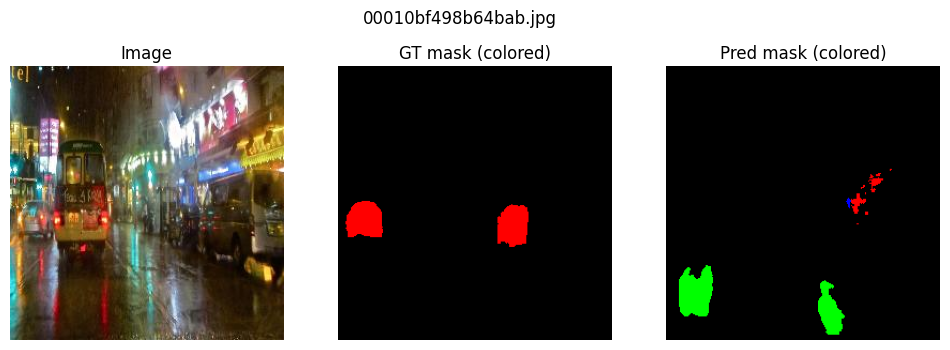

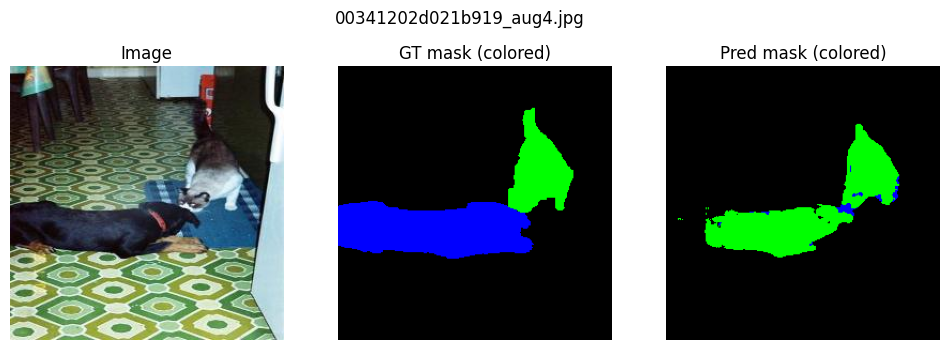

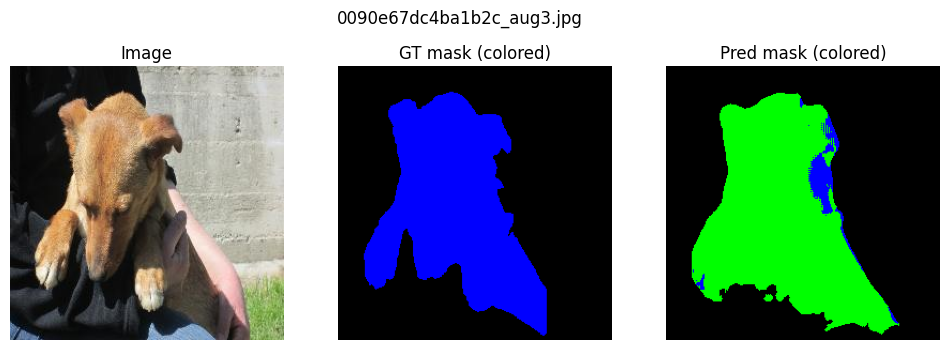

In [21]:
# test with test set
visualize_predictions(model_torch, test_img_dir, test_mask_dir, device, num_samples=3)

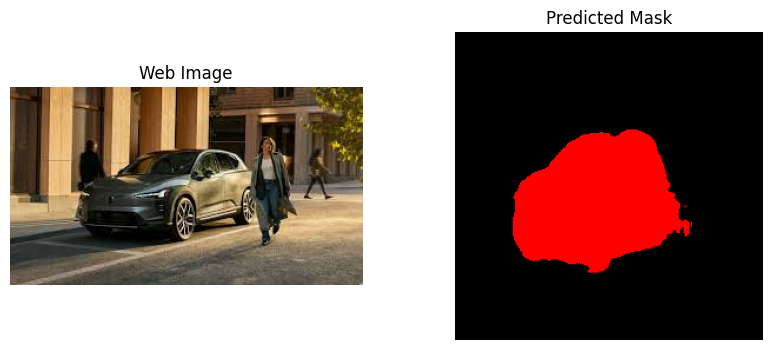

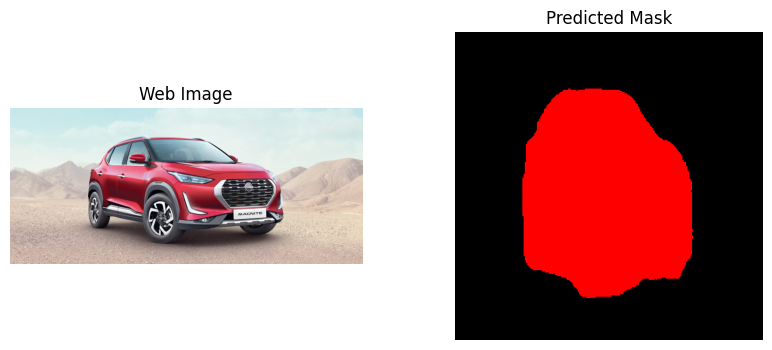

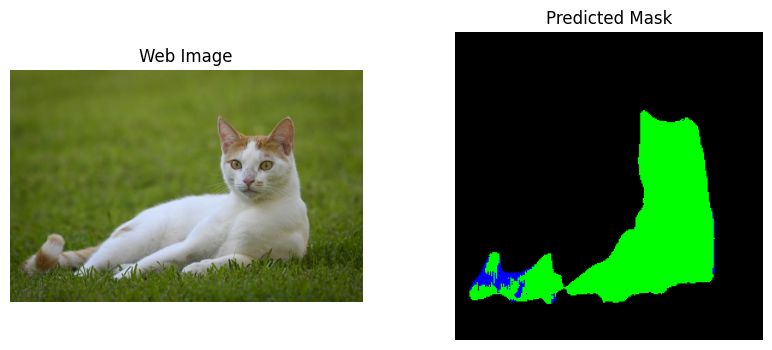

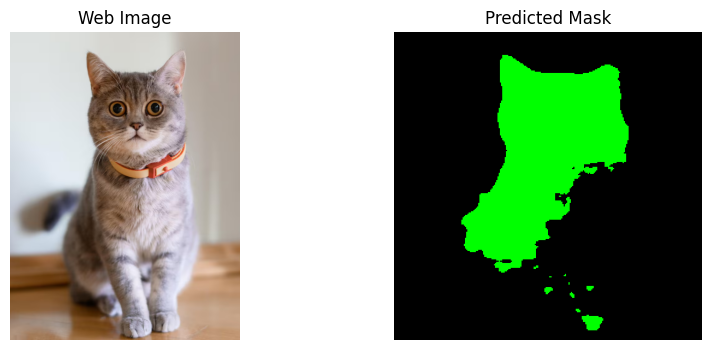

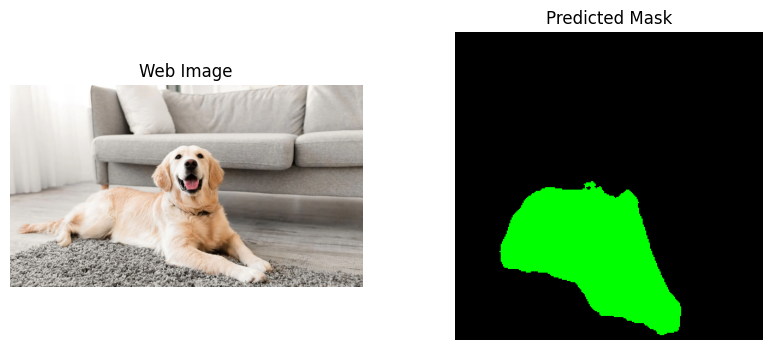

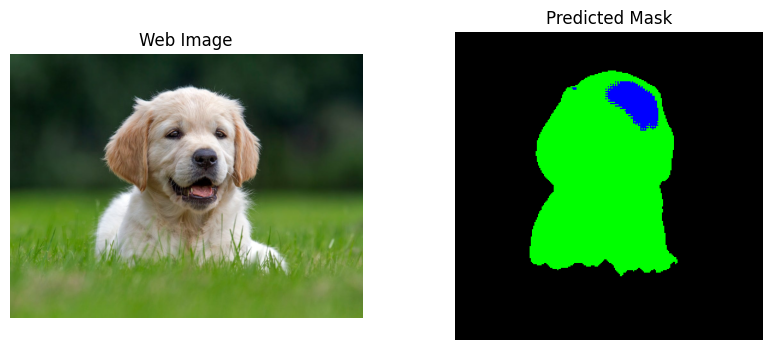

In [22]:
# test with web images
web_images_dir = "/Users/jekaterinasergejeva/Desktop/Masters/Task1_dl/web_images"
web_image_paths = sorted([os.path.join(web_images_dir, f) for f in os.listdir(web_images_dir) if f.endswith('.jpg')])

for img_path in web_image_paths:
    img_tensor = preprocess_web_image(img_path).to(device)
    
    model_torch.eval()
    with torch.no_grad():
        logits = model_torch(img_tensor)  # (1, C, H, W)
        preds = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()  # (H, W)

    pred_colored = colorize_mask(preds)
    
    img = np.array(Image.open(img_path).convert("RGB"))
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Web Image")
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(pred_colored)
    plt.title("Predicted Mask")
    plt.axis("off")
    plt.show()